In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy.ndimage import distance_transform_edt, center_of_mass
from skimage import io
from skimage.measure import regionprops
from skimage.segmentation import find_boundaries
import sys
import tifffile as tf

sys.path.append("../src")
from truncated_graphs import distance_to_border

Dataset:
-   Tumor stroma mask: binary mask
-   OMEnMasks/Basel_Zuri_mask: Cell segmentation masks
-   ome: Multi-channel staining images
-   Data publication: evaluation results
-   Resolution: 1um/pixel
-   Radius graphs with r<=4um

Strategy:
- Calculate cell centroids
- Calculate tumor/stroma borders
- Analyze in tumor/in stroma cells separately
- Distance to ROI border: distance to rectangular image frame
- Distance to tumor/stroma border: distance to mask borders in segmentation file

In [2]:
def match_files(cell_dir, tumor_dir):
    cell_files = sorted([f for f in os.listdir(cell_dir) if f.endswith(".tiff")])
    tumor_files = sorted([f for f in os.listdir(tumor_dir) if f.endswith(".tiff")])

    pairs = []
    for cf in cell_files:
        base = cf.replace("_maks.tiff", "")
        for tf in tumor_files:
            if base in tf:
                pairs.append((os.path.join(cell_dir, cf),
                              os.path.join(tumor_dir, tf)))
                break
    return pairs

In [3]:
def load_masks(cell_path, tumor_path):
    cell_mask = io.imread(cell_path)
    tumor_mask = io.imread(tumor_path)
    tumor_mask = (tumor_mask > 0).astype(bool)
    return cell_mask, tumor_mask

In [4]:
def extract_centroids(cell_mask):
    labels = np.unique(cell_mask)
    labels = labels[labels != 0]

    centroids = center_of_mass(
        cell_mask,
        labels=cell_mask,
        index=labels
    )
    return np.array(centroids), np.array(labels)

In [5]:
def assign_tumor_labels(centroids, tumor_mask):
    coords = np.round(centroids).astype(int)
    coords[:, 0] = np.clip(coords[:, 0], 0, tumor_mask.shape[1]-1)
    coords[:, 1] = np.clip(coords[:, 1], 0, tumor_mask.shape[0]-1)
    return tumor_mask[coords[:, 0], coords[:, 1]]

In [6]:
def compute_signed_distance(tumor_mask):
    outside = distance_transform_edt(~tumor_mask)
    inside = distance_transform_edt(tumor_mask)
    return outside - inside

In [7]:
def get_centroid_distances(centroids, dist_map):
    coords = np.round(centroids).astype(int)
    coords[:, 0] = np.clip(coords[:, 0], 0, dist_map.shape[0]-1)
    coords[:, 1] = np.clip(coords[:, 1], 0, dist_map.shape[1]-1)
    return dist_map[coords[:, 0], coords[:, 1]]

In [8]:
def process_pair(cell_path, tumor_path):
    cell_mask, tumor_mask = load_masks(cell_path, tumor_path)

    centroids, labels = extract_centroids(cell_mask)
    tumor_flags = assign_tumor_labels(centroids, tumor_mask)
    dist_map = compute_signed_distance(tumor_mask)
    distances = get_centroid_distances(centroids, dist_map)
    distances_to_ROI = distance_to_border(centroids)

    df = pd.DataFrame({
        "cell_id": labels,
        "x": centroids[:, 0],
        "y": centroids[:, 1],
        "is_tumor": tumor_flags,
        "dist_to_tumor_boundary": distances,
        "distance_to_border": distances_to_ROI
    })

    return df

In [9]:
def process_all(cell_dir, tumor_dir):
    pairs = match_files(cell_dir, tumor_dir)

    all_dfs = []
    for cell_path, tumor_path in pairs:
        print(f"Processing: {os.path.basename(cell_path)}")

        df = process_pair(cell_path, tumor_path)
        df["image"] = os.path.basename(cell_path)
        if len(df) > 200:
            all_dfs.append(df)
            break
        
    return pd.concat(all_dfs, ignore_index=True)

In [10]:
df = process_all(cell_dir="/data/bionets/datasets/jackson_et_al/OMEnMasks/Basel_Zuri_masks/", tumor_dir="/data/bionets/datasets/jackson_et_al/TumorStroma_masks/")

Processing: BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20170905_100_239_X12Y3_177_a0_full_maks.tiff
Processing: BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20170905_101_141_X12Y2_104_a0_full_maks.tiff


In [18]:
df

,cell_id,x,y,is_tumor,dist_to_tumor_boundary,distance_to_border,image
0,1,2.795918,183.928571,False,270.985239,0.858418,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
1,2,2.357143,419.714286,False,107.967588,0.419643,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
2,3,2.462264,552.490566,False,20.000000,0.524764,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
3,4,1.937500,17.250000,False,227.316959,0.000000,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
4,5,6.500000,39.000000,False,223.056047,4.562500,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
...,...,...,...,...,...,...,...
675,698,579.710526,345.973684,False,62.769419,2.059474,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
676,699,581.154930,116.816901,False,77.781746,0.615070,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
677,700,580.288136,273.194915,False,67.911707,1.481864,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
678,701,581.640351,316.228070,False,72.111026,0.129649,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...


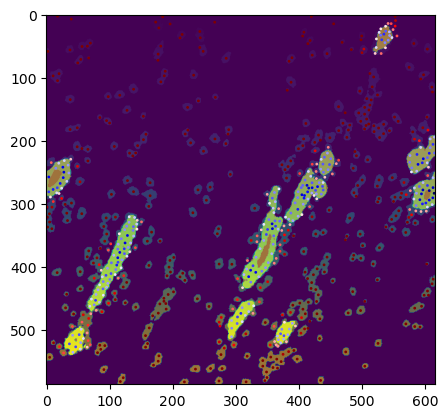

In [20]:
plt.imshow(cell_mask, alpha=1)
plt.imshow(tumor_mask, alpha=0.5)
plt.scatter(df["y"], df["x"], s=1, c=df["dist_to_tumor_boundary"], cmap='seismic', vmin=-20, vmax=20)

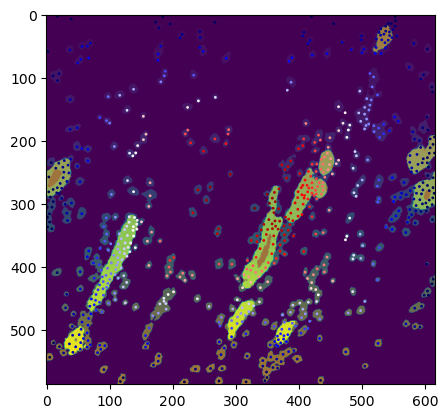

In [21]:
plt.imshow(cell_mask, alpha=1)
plt.imshow(tumor_mask, alpha=0.5)
plt.scatter(df["y"], df["x"], s=1, c=df["distance_to_border"], cmap='seismic')